# Logistic Regression Training for Zero-Knowledge Proof
This notebook trains a logistic regression model on network traffic data for use in a Groth16 zkSNARK proof system. The model's weights and bias are exported for use in Circom circuits.

### Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Step 2: Load and Preprocess Data

In [2]:
# Load dataset (same as random forest training)
df = pd.read_csv('dataset/0.01percent_2classes.csv')
print(f"Dataset loaded — shape: {df.shape}")

# Features and target (same convention: 1 = attack, 0 = benign)
X = df.drop('benign', axis=1)
y = (~df['benign']).astype(int)

print(f"\nTarget distribution (1=attack, 0=benign):")
print(y.value_counts())
print(f"\nClass balance (%):")
print(y.value_counts(normalize=True) * 100)

# Encode categorical columns (reuse same approach as RF notebook)
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nCategorical columns: {categorical_cols}")

X_encoded = X.copy()
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col])
    le_dict[col] = le
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Scale features — important for logistic regression convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=X_encoded.columns)

# Train/test split (same seed as RF for fair comparison)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain size: {X_train.shape}, Test size: {X_test.shape}")

Dataset loaded — shape: (466657, 47)

Target distribution (1=attack, 0=benign):
benign
1    455673
0     10984
Name: count, dtype: int64

Class balance (%):
benign
1    97.646237
0     2.353763
Name: proportion, dtype: float64

Categorical columns: ['protocol_type']
  protocol_type: {'3PC': np.int64(0), 'ARGUS (deprecated)': np.int64(1), 'BBN-RCC-MON': np.int64(2), 'CBT': np.int64(3), 'CHAOS': np.int64(4), 'DCCP': np.int64(5), 'DCN-MEAS': np.int64(6), 'DDP': np.int64(7), 'EGP': np.int64(8), 'EMCON': np.int64(9), 'GGP': np.int64(10), 'GRE': np.int64(11), 'HMP': np.int64(12), 'HOPOPT': np.int64(13), 'ICMP': np.int64(14), 'IDPR': np.int64(15), 'IDPR-CMTP': np.int64(16), 'IDRP': np.int64(17), 'IGMP': np.int64(18), 'IGP': np.int64(19), 'IL': np.int64(20), 'IPv4': np.int64(21), 'IPv6': np.int64(22), 'IPv6-Frag': np.int64(23), 'IPv6-Route': np.int64(24), 'IRTP': np.int64(25), 'ISO-TP4': np.int64(26), 'LEAF-1': np.int64(27), 'LEAF-2': np.int64(28), 'MERIT-INP': np.int64(29), 'MFE-NSP': np.int6

/tmp/ipykernel_1976770/3769425454.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()



Train size: (373325, 46), Test size: (93332, 46)


### Step 3: Define the Model

Logistic regression computes a linear risk score:

$$score = \mathbf{w} \cdot \mathbf{x} + b$$

The binary decision is:

$$\hat{y} = \begin{cases} 1 \text{ (attack)} & \text{if } score > 0 \\ 0 \text{ (benign)} & \text{otherwise} \end{cases}$$

This linear threshold structure is what makes it encodable in a Circom arithmetic circuit for Groth16.

### Step 4: Configure Training Parameters

In [3]:
lr_model = LogisticRegression(
    C=1.0,                   # Inverse regularization strength (1/lambda)
    penalty='l2',            # L2 regularization to prevent overfitting
    solver='lbfgs',          # Efficient solver for medium-sized datasets
    class_weight='balanced', # Handle class imbalance (same as RF)
    max_iter=1000,           # Ensure convergence
    random_state=42
)

print("Model configured:")
print(f"  Solver:       {lr_model.solver}")
print(f"  Penalty:      {lr_model.penalty}")
print(f"  C (1/lambda): {lr_model.C}")
print(f"  Class weight: {lr_model.class_weight}")

Model configured:
  Solver:       lbfgs
  Penalty:      l2
  C (1/lambda): 1.0
  Class weight: balanced


### Step 5: Train the Model

In [4]:
print("Training Logistic Regression model...")
lr_model.fit(X_train, y_train)
print("✓ Training complete!")

print(f"\nModel info:")
print(f"  Features:    {lr_model.n_features_in_}")
print(f"  Iterations:  {lr_model.n_iter_[0]}")
print(f"  Converged:   {lr_model.n_iter_[0] < lr_model.max_iter}")

Training Logistic Regression model...


/home/shafi/Research/Cryptograohy Course/ML-ZeroKnowledge-Proof/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


✓ Training complete!

Model info:
  Features:    46
  Iterations:  148
  Converged:   True


### Step 6: Evaluate Model Performance

MODEL EVALUATION ON TEST SET

Classification Report (1=Attack, 0=Benign):
------------------------------------------------------------
              precision    recall  f1-score   support

      Benign       0.56      0.99      0.72      2197
      Attack       1.00      0.98      0.99     91135

    accuracy                           0.98     93332
   macro avg       0.78      0.99      0.85     93332
weighted avg       0.99      0.98      0.98     93332

Confusion Matrix:
                 Predicted
                 Benign  Attack
Actual Benign      2184      13
       Attack      1723   89412

Key Metrics:
  Accuracy:  0.9814
  Precision: 0.9999
  Recall:    0.9811
  F1-Score:  0.9904
  ROC-AUC:   0.9951


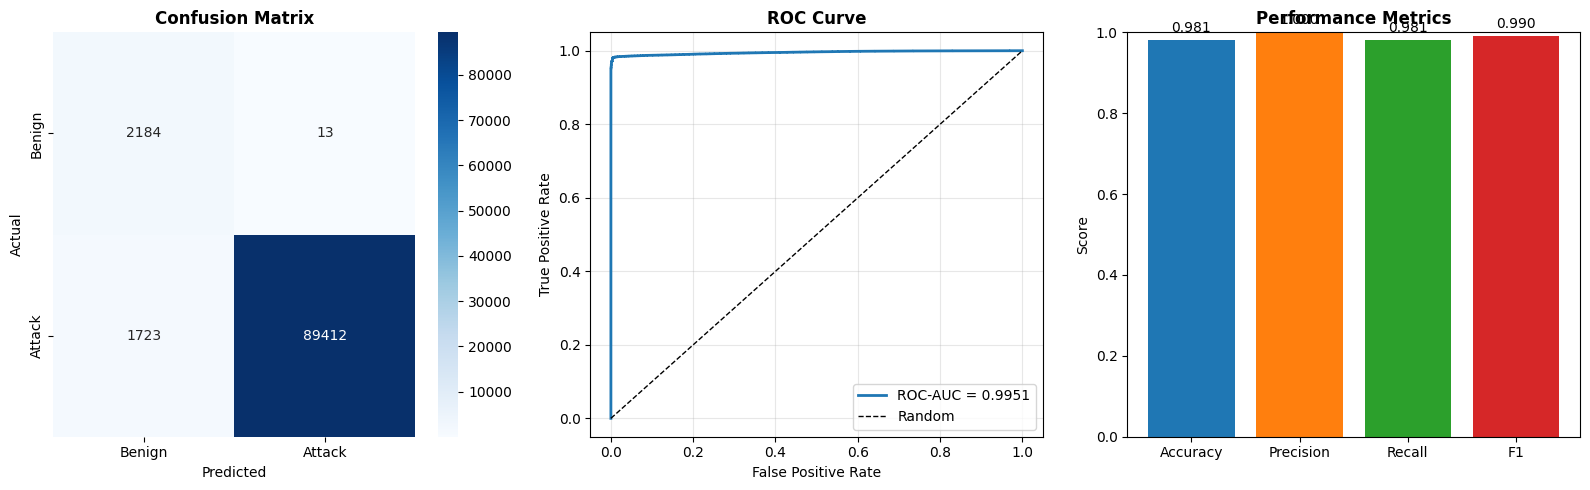

In [5]:
y_pred       = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("MODEL EVALUATION ON TEST SET")
print("=" * 60)

print("\nClassification Report (1=Attack, 0=Benign):")
print("-" * 60)
print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Benign  Attack")
print(f"Actual Benign    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"       Attack    {cm[1,0]:6d}  {cm[1,1]:6d}")

print(f"\nKey Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {roc_auc:.4f}")
print("=" * 60)

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

# Metric bar chart
metrics = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1}
axes[2].bar(metrics.keys(), metrics.values(), color=['#1f77b4','#ff7f0e','#2ca02c','#d62728'])
axes[2].set_ylim([0, 1]); axes[2].set_ylabel('Score')
axes[2].set_title('Performance Metrics', fontweight='bold')
for i, (k, v) in enumerate(metrics.items()):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Step 7: Save the Trained Model

Save the model, scaler, and label encoders. Additionally export the weights and bias as JSON for use in the Circom circuit.

In [6]:
# Save sklearn model, scaler, and label encoders
joblib.dump(lr_model,  'models/lr_model.pkl')
joblib.dump(scaler,    'models/lr_scaler.pkl')
joblib.dump(le_dict,   'models/label_encoders.pkl')
print("✓ Model saved to:         models/lr_model.pkl")
print("✓ Scaler saved to:        models/lr_scaler.pkl")
print("✓ Label encoders saved to: models/label_encoders.pkl")

# Export weights and bias as JSON for Circom circuit
weights = lr_model.coef_[0].tolist()    # shape: (n_features,)
bias    = float(lr_model.intercept_[0])

circuit_params = {
    "feature_names": list(X_encoded.columns),
    "weights": weights,
    "bias": bias,
    "n_features": len(weights),
    "threshold": 0.0   # decision boundary: score > 0 => attack
}

with open('models/lr_circuit_params.json', 'w') as f:
    json.dump(circuit_params, f, indent=2)
print("✓ Circuit parameters saved to: models/lr_circuit_params.json")

# Summary
print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"✓ Trained on {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"✓ Recall:    {recall:.4f}  (catching {recall*100:.1f}% of attacks)")
print(f"✓ Precision: {precision:.4f}  (false alarm rate: {1-precision:.4f})")
print(f"✓ ROC-AUC:   {roc_auc:.4f}")
print(f"✓ Circuit: dot product of {len(weights)} weights — ready for Circom")
print("=" * 60)

✓ Model saved to:         models/lr_model.pkl
✓ Scaler saved to:        models/lr_scaler.pkl
✓ Label encoders saved to: models/label_encoders.pkl
✓ Circuit parameters saved to: models/lr_circuit_params.json

TRAINING SUMMARY
✓ Trained on 373325 samples, 46 features
✓ Recall:    0.9811  (catching 98.1% of attacks)
✓ Precision: 0.9999  (false alarm rate: 0.0001)
✓ ROC-AUC:   0.9951
✓ Circuit: dot product of 46 weights — ready for Circom
